<a href="https://colab.research.google.com/github/georginadd/EMSC2010_major_project/blob/main/EMSC2010_Major_Assignment_u7925896.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Major Assignment - Investigating the Relationship Between Ocean Temperature and Coral Bleaching in Australian Reefs


# Project Overview

**Dataset selection & cleaning**

Data was found from BCO-DMO; “Experimental and in situ seawater nutrient data collected as part of a study of pCO2 variability on the reef-building coral Pocillopora damicornis conducted at Heron Island Research Station, Heron Island, southern Great Barrier Reef in 2021”. This was downloaded as a csv file and loaded into the colab notebook.

**Citation:** Barott, K., Brown, K. T. (2023). Experimental and in situ seawater nutrient data collected as part of a study of pCO2 variability on the reef-building coral Pocillopora damicornis conducted at Heron Island Research Station, Heron Island, southern Great Barrier Reef in 2021. Biological and Chemical Oceanography Data Management Office (BCO-DMO). (Version 1) Version Date 2022-12-20. doi:10.26008/1912/bco-dmo.885669.1


**METADATA**:


AIM:


DATA PREPARATION & COLLECTION:


using:


*   time series analysis
*   correlation/regression
*   hypothesis testing?
*   bootstrapping


**Aims:**


**Load in and clean dataset**

In [81]:
import pandas as pd
nutrients = pd.read_csv("infield_nutrients.csv")

# create a continuous time variable
nutrients['DateTime'] = pd.to_datetime(nutrients['Date'].astype(str) + ' ' + nutrients['Time'].astype(str))

nutrients['Decimal_Time'] = (nutrients['DateTime'] - nutrients['DateTime'].min()
).dt.total_seconds() / (24*60*60)
print(nutrients[['Date', 'Time', 'Decimal_Time']].head())




         Date   Time  Decimal_Time
0  2021-01-15  09:30       0.00000
1  2021-01-15  09:30       0.00000
2  2021-01-15  09:30       0.00000
3  2021-01-15  10:15       0.03125
4  2021-01-15  10:15       0.03125


Install relevant packages

In [17]:
!pip install bambi #system command to install bambi package

# Import required packages for data handling, plotting, modelling, and model comparison

import numpy as np
import matplotlib.pyplot as plt
import bambi as bmb
import arviz as az
import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.8/237.8 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.9/179.9 kB 19.7 MB/s eta 0:00:00
  Attempting uninstall: pytensor
    Found existing installation: pytensor 2.38.3
    Uninstalling pytensor-2.38.3:
      Successfully uninstalled pytensor-2.38.3
  Attempting uninstall: arviz
    Found existing installation: arviz 0.22.0
    Uninstalling arviz-0.22.0:
      Successfully uninstalled arviz-0.22.0
  Attempting uninstall: pymc
    Found existing 

# Time series analysis

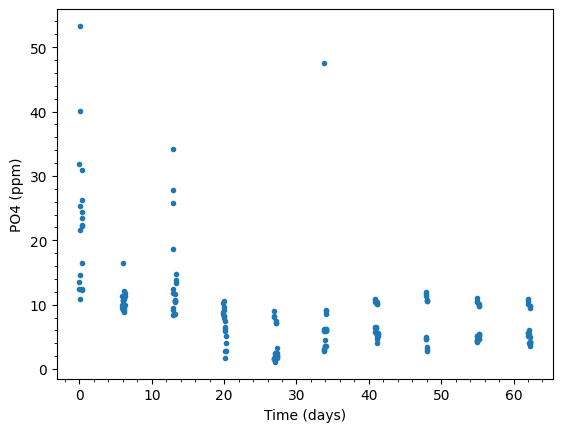

In [135]:
plt.plot(nutrients.Decimal_Time,nutrients.PO4_P,'.') #plot the data
plt.xlabel('Time (days)') #label the x-axis
plt.ylabel('PO4 (ppm)') #label the y-axis
plt.minorticks_on() #add minorticks to the plot

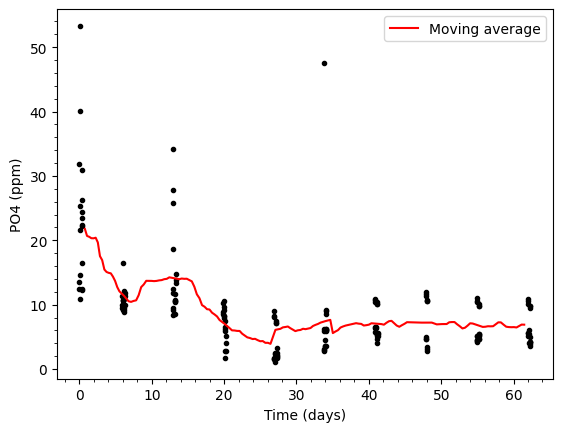

In [136]:
# calculate moving average
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

w = 20 # length of the moving average
PO4_s = moving_average(nutrients.PO4_P, w) # process the signal
Time_s = moving_average(nutrients.Decimal_Time, w) # process the times

plt.plot(nutrients.Decimal_Time,nutrients.PO4_P, '.k') #plot the data
plt.plot(Time_s,PO4_s,'r', label="Moving average")
plt.legend()

plt.xlabel('Time (days)')
plt.ylabel('PO4 (ppm)')
plt.minorticks_on()

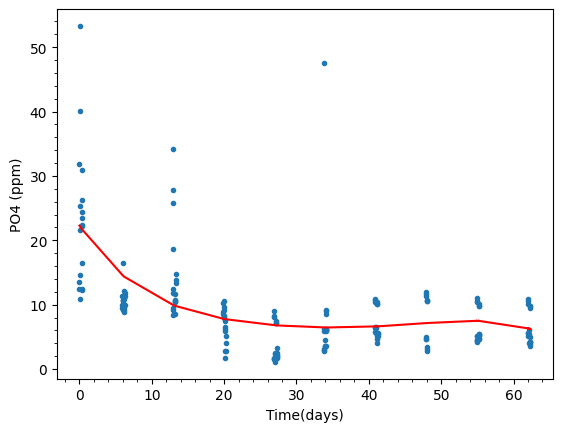

In [137]:
# separate short term & long term trends
#polyfit function just give polynomial with least squares regression (39 mins)
order = 5 #set the polynomial order
pp = np.polyfit(nutrients.Decimal_Time,nutrients.PO4_P,order) #fit the polynomial, pp will contain the polynomial coefficients
trend = np.polyval(pp,nutrients.Decimal_Time) #find the value of the polynomial at each time point.

plt.plot(nutrients.Decimal_Time,nutrients.PO4_P,'.') #plot the data
plt.plot(nutrients.Decimal_Time,trend,'r') #plot the trend
plt.xlabel('Time(days)') #label the x-axis
plt.ylabel('PO4 (ppm)') #label the y-axis
plt.minorticks_on() #add minorticks to the plot

Next we'll calculate the residuals, which are the differences between the data and the fitted polynomial trend. We can compare both the trend and the residuals in a plot.

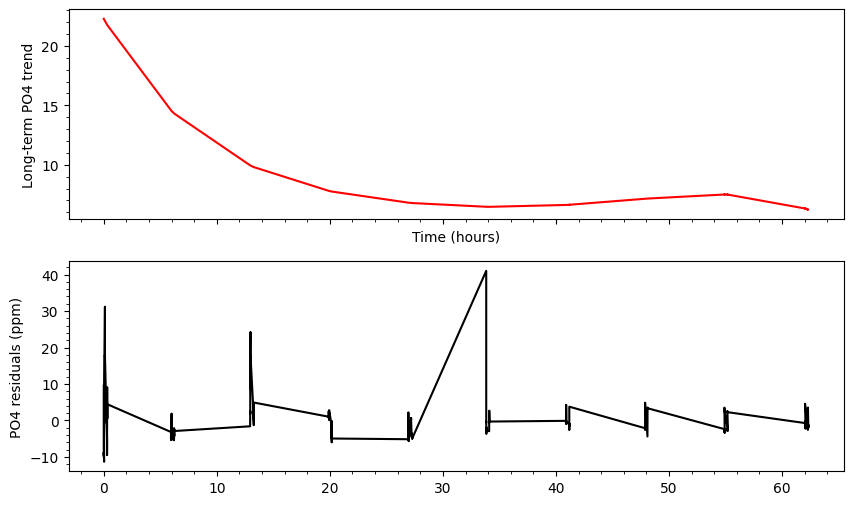

In [111]:
residuals = nutrients.PO4_P-trend #find the residuals
fig, axes = plt.subplots(2,1, figsize=(10, 6), sharex = True) #make 2 subplots with the same x-axis

axes[0].plot(nutrients.Decimal_Time,trend,'r') #plot the polynomial trend
axes[1].plot(nutrients.Decimal_Time,residuals,'k') #plot the residuals

axes[0].set_xlabel('Time (hours)') #label the x-axis
axes[0].set_ylabel('Long-term PO4 trend') #label the trend y-axis
axes[1].set_ylabel('PO4 residuals (ppm)') #label the residual y-axis

axes[0].minorticks_on() #add minorticks
axes[1].minorticks_on() #add minorticks

These abrupt residuals are likely a result of tidal cycles.

In [ ]:
# frequency spectrum analysis

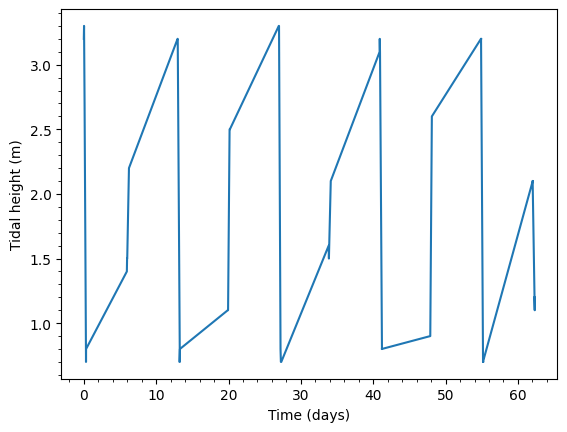

In [138]:
plt.plot(nutrients.Decimal_Time,nutrients.Tidal_height) #plot the data
plt.xlabel('Time (days)') #label the x-axis
plt.ylabel('Tidal height (m)') #label the y-axis
plt.minorticks_on() #add minorticks to the plot

In [124]:
#Defining functions for frequency and filters
def freq_spectrum(time,signal):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT (positive freqs only)
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  # Amplitude: scale by 2/n so each peak height equals the true amplitude
  amplitude = (2 / n) * np.abs(fft_vals)
  amplitude[0] /= 2

  return freqs, amplitude

def lowpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

    #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs>cutoff] = 0.0 #cycles above the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal


def highpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqscutoff[1]] = 0.0 #cycles above cutoff[1] are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal


def bandpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs<cutoff[0]] = 0.0 #cycles below cutoff[0] are given an amplitude of 0
  fft_vals[freqs>cutoff[1]] = 0.0 #cycles above cutoff[1] are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

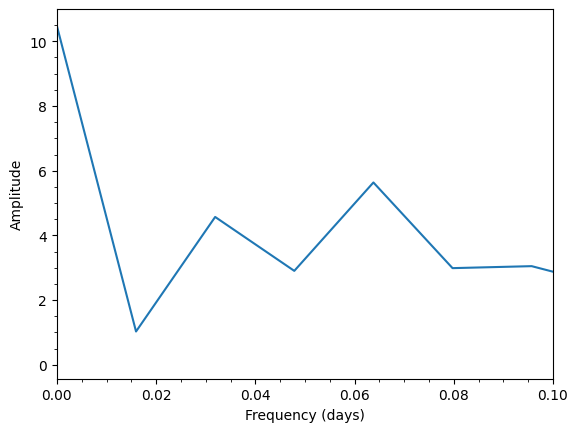

In [139]:
Time = nutrients['Decimal_Time'].values #get the age values as a numpy array
Phosphate = nutrients['PO4_P'].values #get the d18O values as a numpy array

freqs, amps = freq_spectrum(Time,Phosphate) #calculate the frequency spectrum
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency (days)') #label the x-axis
plt.ylabel('Amplitude') #label the y-axis
plt.xlim([0,0.1]) #limits the x-axis
plt.minorticks_on() #add minorticks

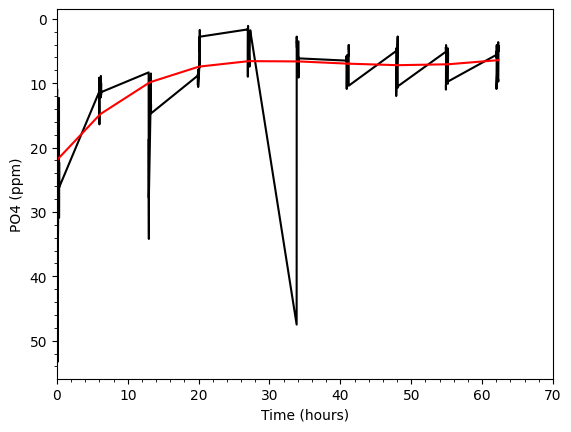

In [140]:
# detrend the data
pp = np.polyfit(Time,Phosphate,4) #fit a trendline to the data
plt.plot(Time,Phosphate,'k') #plot the original data
plt.plot(Time,np.polyval(pp,Time),'r') #plot the trendline
plt.xlabel('Time (hours)') #label the x-axis
plt.ylabel(r'PO4 (ppm)') #label the y-axis
plt.gca().invert_yaxis() #invert the y-axis
plt.xlim([0,70]) #limit the x-axis
plt.minorticks_on() #add minorticks

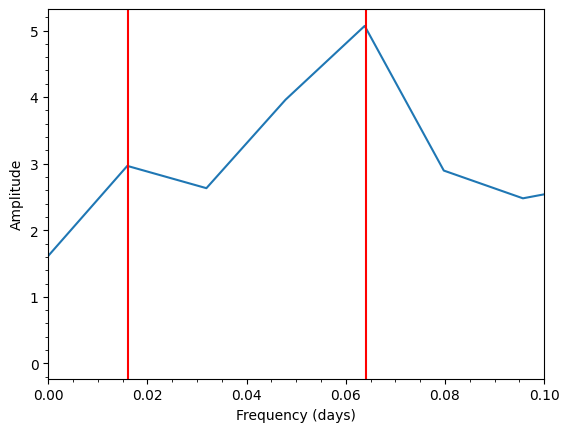

In [141]:
detrend = Phosphate-np.polyval(pp,Time) #calculate the detrended data
freqs, amps = freq_spectrum(Time,detrend) #frequency spectrum of the detrended data
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency (days)') #label the x-axis
plt.ylabel('Amplitude') #label the y-axis
plt.xlim([0,0.1]) #limits the x-axis
plt.minorticks_on() #add minorticks
plt.gca().axvline(x=0.064,color='r')
plt.gca().axvline(x=0.016,color='r')

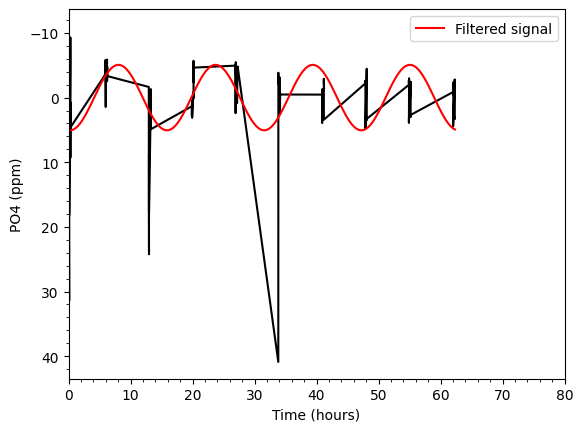

In [144]:
plt.plot(Time,detrend,'k') #plot the detrended data
x, y = bandpass_filter(Time,detrend,[0.06,0.065]) #obtain the filtered signal
plt.plot(x,y,'r', label = 'Filtered signal') #plot the filtered signal
plt.xlabel('Time (hours)') #label the x-axis
plt.ylabel(r'PO4 (ppm)') #label the y-axis
plt.legend()
plt.gca().invert_yaxis() #invert the y-axis
plt.xlim([0,80]) #limit the x-axis
plt.minorticks_on() #add minorticks

The above sine curve represents the effect of tides on PO4 concentrations.

# Correlation/Regression

# Bootstrapping

# Conclusions

This project was limitated in that the dataset was only over a time frame of 3 months, so longer term trends could not be included in this analysis.



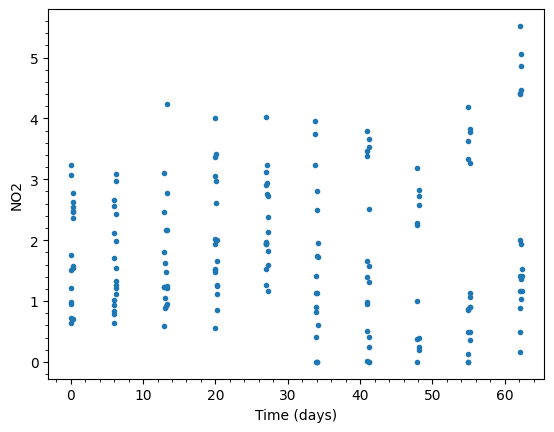

In [76]:
plt.plot(nutrients.Decimal_Time,nutrients.NO2_N,'.') #plot the data
plt.xlabel('Time (days)') #label the x-axis
plt.ylabel('NO2') #label the y-axis
plt.minorticks_on() #add minorticks to the plot

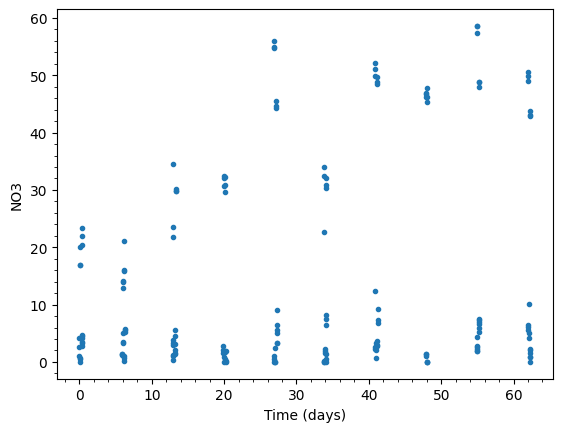

In [77]:
plt.plot(nutrients.Decimal_Time,nutrients.NO3_N,'.') #plot the data
plt.xlabel('Time (days)') #label the x-axis
plt.ylabel('NO3') #label the y-axis
plt.minorticks_on() #add minorticks to the plot

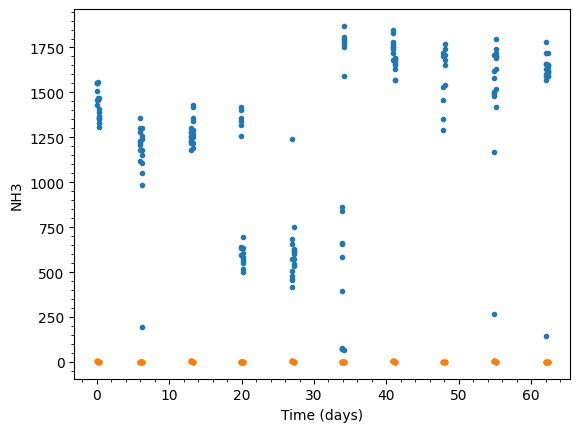

In [85]:
plt.plot(nutrients.Decimal_Time,nutrients.NH3_N,'.') #plot the data
plt.plot(nutrients.Decimal_Time,nutrients.Tidal_height,'.') #plot the data
plt.xlabel('Time (days)') #label the x-axis
plt.ylabel('NH3') #label the y-axis
plt.minorticks_on() #add minorticks to the plot

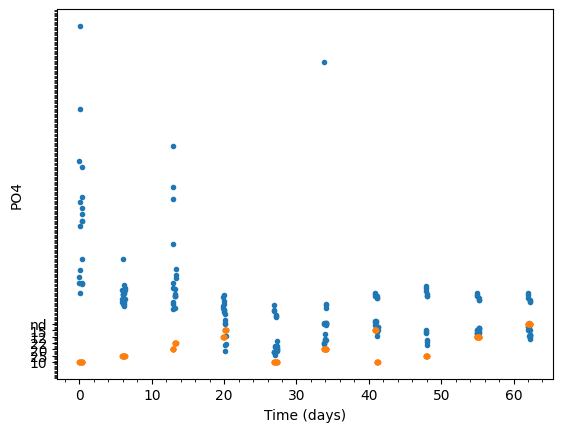

In [80]:
plt.plot(nutrients.Decimal_Time,nutrients.PO4_P,'.') #plot the data
plt.plot(nutrients.Decimal_Time,nutrients.Wind,'.') #plot the data
plt.xlabel('Time (days)') #label the x-axis
plt.ylabel('PO4') #label the y-axis
plt.minorticks_on() #add minorticks to the plot